# Pertemuan 6 — CIFAR-10: Custom CNN Feature Maps → SVM

Notebook **training** untuk Tugas 2.

## Alur
1. Memuat **official training split CIFAR-10 saja** (50.000 gambar).
2. Membagi official training split menjadi:
   - 40.000 training images
   - 10.000 validation images
3. Membuat dan melatih **custom CNN**.
4. Mengekstrak dan memvisualisasikan **feature maps**.
5. Membentuk **512-dimensional feature vector** dari CNN.
6. Melakukan **Grid Search** pada RBF-SVM.
7. Melatih final SVM menggunakan CNN features.
8. Menyimpan **CNN + SVM dalam satu file HDF5 (`.h5`)**.

> Official CIFAR-10 test split tidak dimuat ke variabel training dan tidak digunakan untuk training atau tuning.
> Validation set hanya digunakan untuk monitoring dan pemilihan model; bobot CNN diperbarui hanya dari training set.

In [1]:
import os
import gc
import random
import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 23092026

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

I0000 00:00:1790496167.849872   34888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790496167.887803   34888 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790496168.913034   34888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load CIFAR-10

CIFAR-10 berisi 60.000 gambar RGB berukuran 32×32 pada 10 kelas.

Notebook training hanya mengambil **50.000 training images resmi CIFAR-10**.  
10.000 test images disimpan untuk notebook testing.

In [2]:
# Di notebook training ini kita hanya mengambil official_train.
# Official test split dibuang dengan `_` dan tidak dipakai sama sekali.
(X_train_full, y_train_full), _ = cifar10.load_data()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("Official CIFAR-10 training images:", X_train_full.shape)
print("Official CIFAR-10 training labels:", y_train_full.shape)

Official CIFAR-10 training images: (50000, 32, 32, 3)
Official CIFAR-10 training labels: (50000, 1)


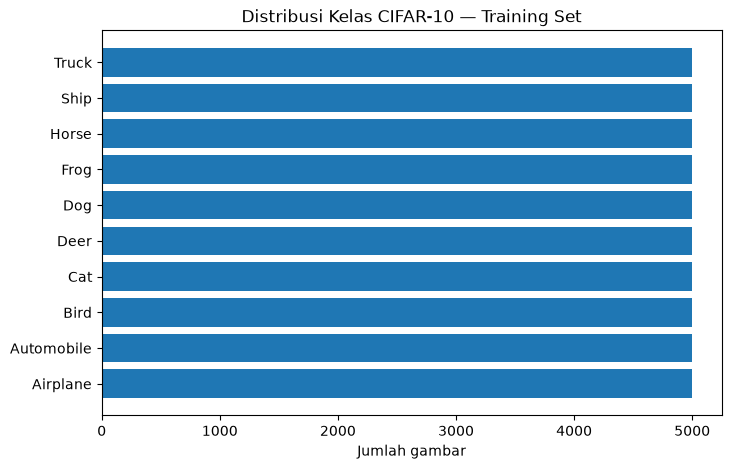

In [3]:
classes, counts = np.unique(y_train_full, return_counts=True)

plt.figure(figsize=(8, 5))
plt.barh(classes_name, counts)
plt.title("Distribusi Kelas CIFAR-10 — Training Set")
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Tampilkan Contoh Gambar CIFAR-10

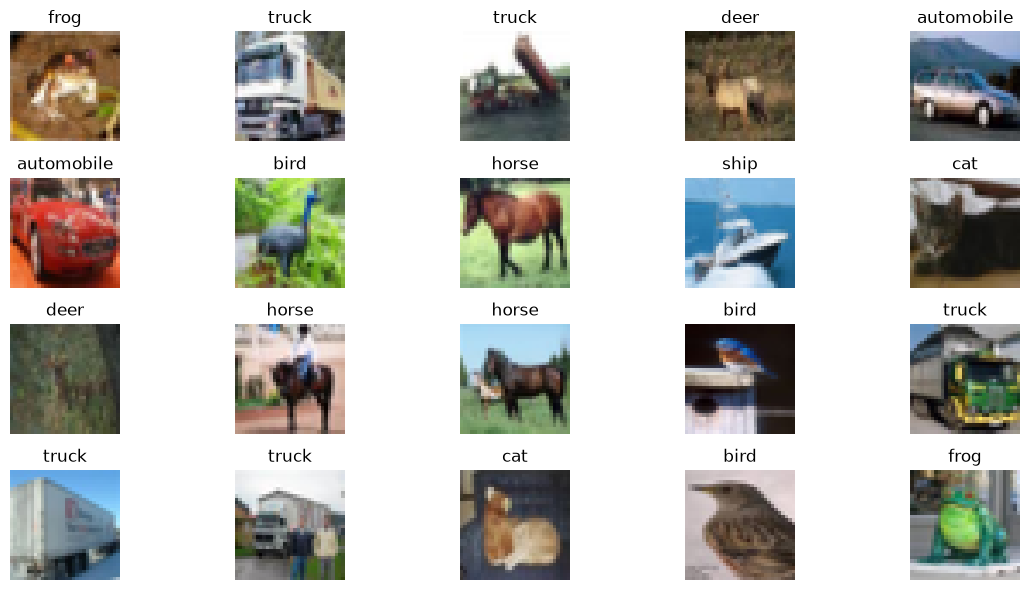

In [4]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(labels[int(y_train_full[i, 0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocessing dan Train/Validation Split

`cifar10.load_data()` menyediakan dua official split:

```text
50.000 official training images
10.000 official test images
```

Notebook ini **hanya mengambil 50.000 official training images**.

Dari 50.000 training images tersebut dibuat:
- **40.000 training images** untuk gradient update pada `model.fit()`
- **10.000 validation images** untuk menghitung `val_loss` dan `val_accuracy`

Validation set tidak digunakan oleh optimizer untuk memperbarui bobot.

Preprocessing:
- normalisasi pixel `0..255 → 0..1`
- stratified split
- `random_state = 23092026`

In [5]:
# Normalisasi hanya official training split.
X_train_full = X_train_full.astype("float32") / 255.0
y_train_full = y_train_full.flatten()

# Validation diambil dari official training split.
# X_val/y_val TIDAK digunakan untuk gradient update.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

y_cat_train = to_categorical(y_train, 10)
y_cat_val = to_categorical(y_val, 10)

print("Training data   :", X_train.shape, y_train.shape)
print("Validation data :", X_val.shape, y_val.shape)
print()
print("Data yang benar-benar digunakan model.fit() untuk update bobot:")
print("X_train =", X_train.shape)
print("y_train =", y_train.shape)

Training data   : (40000, 32, 32, 3) (40000,)
Validation data : (10000, 32, 32, 3) (10000,)

Data yang benar-benar digunakan model.fit() untuk update bobot:
X_train = (40000, 32, 32, 3)
y_train = (40000,)


# 4. Custom CNN

Model **bukan pretrained model**.

Arsitektur tetap mengikuti konsep CNN awal, tetapi kapasitasnya diperbesar agar representasi feature map lebih kuat untuk CIFAR-10.

Bagian penting:

```text
Input 32×32×3
↓
Conv Block 1 — 64 filters
↓
Conv Block 2 — 128 filters
↓
Conv Block 3 — 256 filters
↓
Conv Block 4 — 512 filters
↓
feature_map (2×2×512)
↓
GlobalAveragePooling2D
↓
svm_features (512 nilai)
↓
Dense classifier
↓
Softmax 10 kelas
```

Layer **`feature_map`** akan divisualisasikan.

Layer **`svm_features`** berasal langsung dari feature map convolution terakhir dan digunakan sebagai input SVM.

In [6]:
INPUT_SHAPE = (32, 32, 3)
WEIGHT_DECAY = 1e-4

def build_custom_cnn():
    inputs = Input(
        shape=INPUT_SHAPE,
        name="input_image"
    )

    # =====================================================
    # BLOCK 1 — 32x32 -> 16x16
    # =====================================================
    x = Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv1_1"
    )(inputs)
    x = BatchNormalization(name="bn1_1")(x)

    x = Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv1_2"
    )(x)
    x = BatchNormalization(name="bn1_2")(x)

    x = MaxPooling2D(
        pool_size=(2, 2),
        name="pool1"
    )(x)
    x = Dropout(0.15, name="dropout1")(x)

    # =====================================================
    # BLOCK 2 — 16x16 -> 8x8
    # =====================================================
    x = Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv2_1"
    )(x)
    x = BatchNormalization(name="bn2_1")(x)

    x = Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv2_2"
    )(x)
    x = BatchNormalization(name="bn2_2")(x)

    x = MaxPooling2D(
        pool_size=(2, 2),
        name="pool2"
    )(x)
    x = Dropout(0.25, name="dropout2")(x)

    # =====================================================
    # BLOCK 3 — 8x8 -> 4x4
    # =====================================================
    x = Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv3_1"
    )(x)
    x = BatchNormalization(name="bn3_1")(x)

    x = Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv3_2"
    )(x)
    x = BatchNormalization(name="bn3_2")(x)

    x = MaxPooling2D(
        pool_size=(2, 2),
        name="pool3"
    )(x)
    x = Dropout(0.35, name="dropout3")(x)

    # =====================================================
    # BLOCK 4 — 4x4 -> 2x2
    # =====================================================
    x = Conv2D(
        512, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="conv4_1"
    )(x)
    x = BatchNormalization(name="bn4_1")(x)

    # Output convolution ini adalah high-level feature maps
    x = Conv2D(
        512, (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="feature_map"
    )(x)
    x = BatchNormalization(name="feature_map_bn")(x)

    x = MaxPooling2D(
        pool_size=(2, 2),
        name="pool4"
    )(x)
    x = Dropout(0.40, name="dropout4")(x)

    # =====================================================
    # FEATURE VECTOR UNTUK SVM
    # =====================================================
    # Setiap channel pada high-level feature map diringkas
    # menjadi satu nilai -> vector 512 dimensi.
    svm_features = GlobalAveragePooling2D(
        name="svm_features"
    )(x)

    # CNN classification head hanya untuk melatih feature extractor
    x = Dense(
        512,
        activation="relu",
        kernel_regularizer=l2(WEIGHT_DECAY),
        name="cnn_dense"
    )(svm_features)
    x = BatchNormalization(name="cnn_dense_bn")(x)
    x = Dropout(0.50, name="cnn_head_dropout")(x)

    outputs = Dense(
        10,
        activation="softmax",
        name="cnn_softmax"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="custom_cifar10_cnn"
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3
    )

    loss = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.10
    )

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    return model

In [7]:
model = build_custom_cnn()
model.summary()

I0000 00:00:1790496171.982286   34888 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3541 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "custom_cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 4, 4, 512)      │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_map (Conv2D)            │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_map_bn                  │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,962,890 (18.93 MB)

 Trainable params: 4,958,026 (18.91 MB)

 Non-trainable params: 4,864 (19.00 KB)

## 5. Data Augmentation

Augmentasi diterapkan hanya pada training data.

In [8]:
BATCH_SIZE = 64

data_generator = ImageDataGenerator(
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.10,
    fill_mode="reflect"
)

train_generator = data_generator.flow(
    X_train,
    y_cat_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

## 6. Train Custom CNN — Maksimum 200 Epoch

200 epoch adalah **batas maksimum**.

Training dapat berhenti lebih awal menggunakan `EarlyStopping`, dan learning rate diturunkan otomatis jika validation loss stagnan.

In [9]:
MODEL_PATH = "cifar10_cnn_svm_model.h5"
MAX_EPOCHS = 200

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),

    # Hanya satu artifact model: HDF5 (.h5)
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    # HANYA X_train/y_train yang menghasilkan gradient update.
    train_generator,
    epochs=MAX_EPOCHS,

    # X_val/y_val hanya untuk monitoring validation metric.
    validation_data=(X_val, y_cat_val),

    callbacks=callbacks,
    verbose=1
)

Epoch 1/200


I0000 00:00:1790496172.869203   34888 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1790496176.059990   34957 service.cc:153] XLA service 0x76841005c6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790496176.060009   34957 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790496176.214151   34957 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790496176.857247   34957 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790496177.039991   34957 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8508__.125
I0000 00:00:1790496179.106234   35032 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion

  5/625 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.1406 - loss: 3.6731

I0000 00:00:1790496192.479339   34957 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3771 - loss: 2.2716
Epoch 1: val_accuracy improved from None to 0.22480, saving model to cifar10_cnn_svm_model.h5


...


Epoch 106: finished saving model to cifar10_cnn_svm_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9709 - loss: 0.7119 - val_accuracy: 0.9218 - val_loss: 0.8283 - learning_rate: 6.2500e-05
Epoch 107/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9700 - loss: 0.7107
Epoch 107: val_accuracy improved from 0.92180 to 0.92510, saving model to cifar10_cnn_svm_model.h5



Epoch 107: finished saving model to cifar10_cnn_svm_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9700 - loss: 0.7107 - val_accuracy: 0.9251 - val_loss: 0.8183 - learning_rate: 6.2500e-05
Epoch 108/200
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9736 - loss: 0.7037
Epoch 108: val_accuracy did not improve from 0.92510
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9736 - loss: 0.7037 - val_accuracy: 0.9231 - val_loss: 0.8252 - learning_rate: 6.2500e-05
Epoch 109/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9744 - loss: 0.7019
Epoch 109: val_accuracy did not improve from 0.92510
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9743 - loss: 0.7019 - val_accuracy: 0.9224 - val_loss: 0.8270 - learning_rate: 6.2500e-05
Epoch 110/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9741 - loss: 0.7009
Epoch 110: val_accuracy did not improve from 0.92510
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9741 - loss


Epoch 127: finished saving model to cifar10_cnn_svm_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9804 - loss: 0.6778 - val_accuracy: 0.9252 - val_loss: 0.8126 - learning_rate: 3.1250e-05
Epoch 128/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9798 - loss: 0.6798
Epoch 128: val_accuracy improved from 0.92520 to 0.92580, saving model to cifar10_cnn_svm_model.h5



Epoch 128: finished saving model to cifar10_cnn_svm_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9797 - loss: 0.6798 - val_accuracy: 0.9258 - val_loss: 0.8115 - learning_rate: 3.1250e-05
Epoch 129/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9798 - loss: 0.6782
Epoch 129: val_accuracy did not improve from 0.92580
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9798 - loss: 0.6782 - val_accuracy: 0.9248 - val_loss: 0.8132 - learning_rate: 3.1250e-05
Epoch 130/200
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9812 - loss: 0.6749
Epoch 130: val_accuracy did not improve from 0.92580
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9812 - loss: 0.6749 - val_accuracy: 0.9243 - val_loss: 0.8134 - learning_rate: 3.1250e-05
Epoch 131/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9802 - loss: 0.6759
Epoch 131: val_accuracy did not improve from 0.92580
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9802 - loss


Epoch 133: finished saving model to cifar10_cnn_svm_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9821 - loss: 0.6722 - val_accuracy: 0.9282 - val_loss: 0.8097 - learning_rate: 3.1250e-05
Epoch 134/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9818 - loss: 0.6732
Epoch 134: val_accuracy did not improve from 0.92820
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9818 - loss: 0.6732 - val_accuracy: 0.9250 - val_loss: 0.8150 - learning_rate: 3.1250e-05
Epoch 135/200
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9811 - loss: 0.6732
Epoch 135: val_accuracy did not improve from 0.92820
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9811 - loss: 0.6732 - val_accuracy: 0.9235 - val_loss: 0.8146 - learning_rate: 3.1250e-05
Epoch 136/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9816 - loss: 0.6708
Epoch 136: val_accuracy did not improve from 0.92820
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9815 - loss

## 7. Training Curve

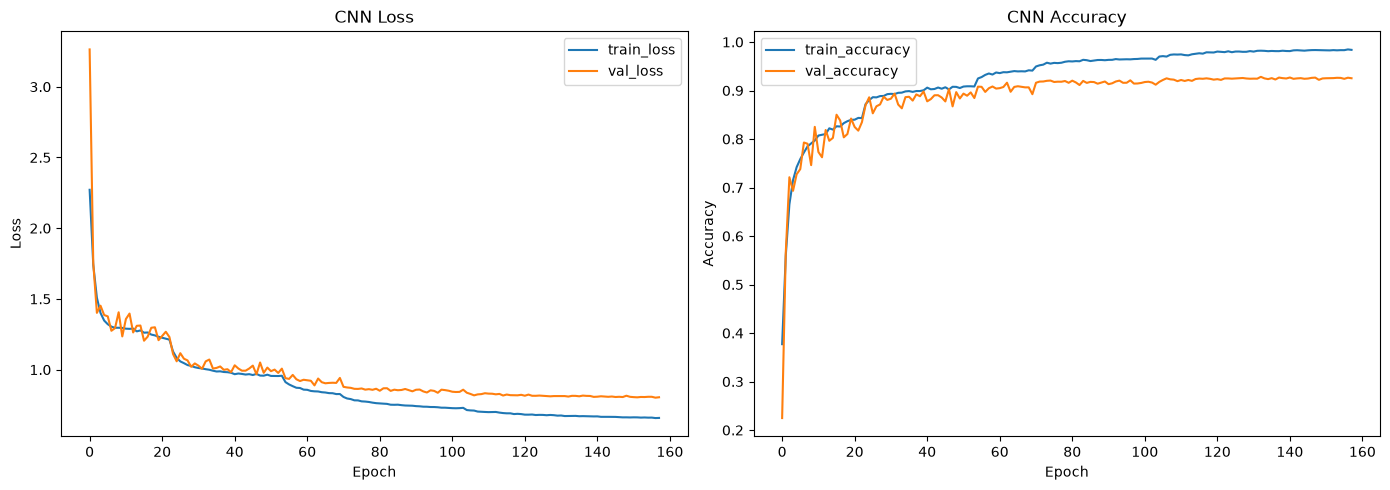

Best epoch: 133
Best validation accuracy during training: 92.82%


In [10]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

best_epoch = int(history_df["val_accuracy"].idxmax() + 1)
best_val_history = float(history_df["val_accuracy"].max())

print("Best epoch:", best_epoch)
print(
    f"Best validation accuracy during training: "
    f"{best_val_history * 100:.2f}%"
)

## 8. Load CNN Terbaik

Seluruh proses feature extraction berikutnya menggunakan checkpoint CNN dengan validation accuracy terbaik.

In [11]:
best_cnn = load_model(
    MODEL_PATH
)

cnn_val_loss, cnn_val_accuracy = best_cnn.evaluate(
    X_val,
    y_cat_val,
    verbose=1
)

print(f"CNN validation loss    : {cnn_val_loss:.4f}")
print(
    f"CNN validation accuracy: "
    f"{cnn_val_accuracy * 100:.2f}%"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9282 - loss: 0.8097
CNN validation loss    : 0.8097
CNN validation accuracy: 92.82%


# 9. Ekstraksi Feature Maps

Bagian ini adalah bagian utama yang menyesuaikan tugas **Extraction of Feature Maps**.

Kita mengambil output beberapa convolution layers:

- `conv1_2` → low-level features
- `conv2_2`
- `conv3_2`
- `feature_map` → high-level features

Kemudian feature maps divisualisasikan untuk satu gambar CIFAR-10.

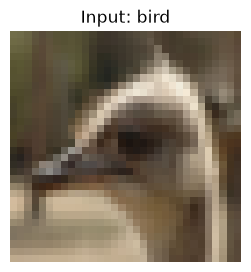

conv1_2: (1, 32, 32, 64) — menampilkan 12 feature maps pertama


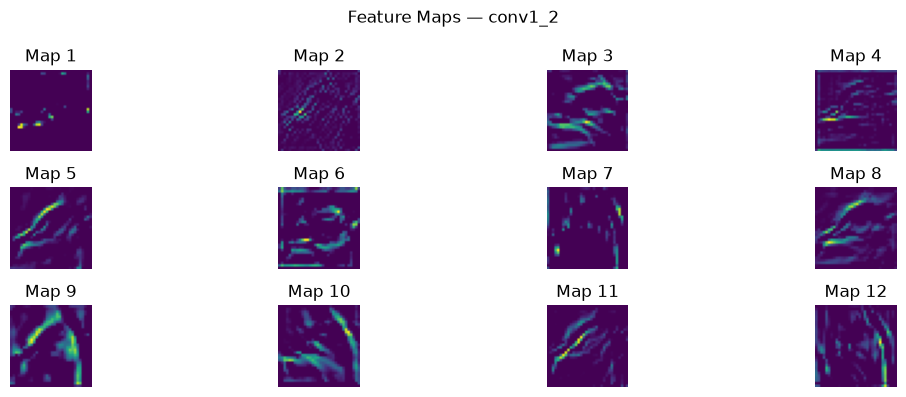

conv2_2: (1, 16, 16, 128) — menampilkan 12 feature maps pertama


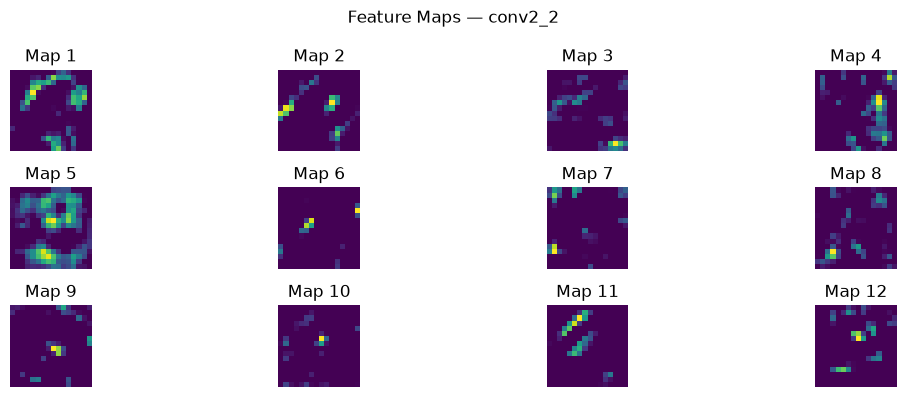

conv3_2: (1, 8, 8, 256) — menampilkan 12 feature maps pertama


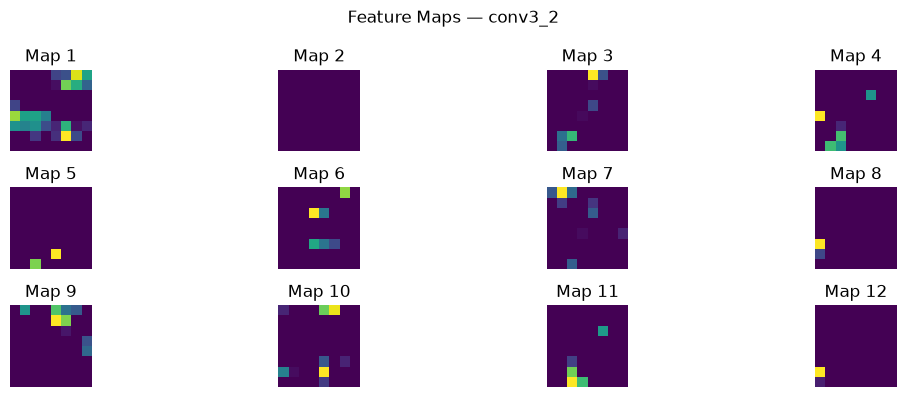

feature_map: (1, 4, 4, 512) — menampilkan 12 feature maps pertama


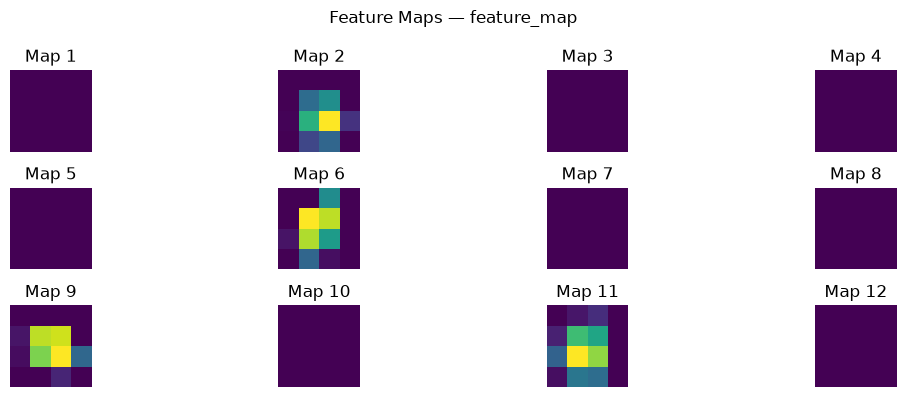

In [12]:
FEATURE_MAP_LAYERS = [
    "conv1_2",
    "conv2_2",
    "conv3_2",
    "feature_map"
]

feature_map_model = Model(
    inputs=best_cnn.input,
    outputs=[
        best_cnn.get_layer(name).output
        for name in FEATURE_MAP_LAYERS
    ],
    name="feature_map_extractor"
)

sample_index = 0
sample_image = X_val[sample_index:sample_index + 1]

feature_maps = feature_map_model.predict(
    sample_image,
    verbose=0
)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(
    f"Input: {labels[y_val[sample_index]]}"
)
plt.axis("off")
plt.show()

for layer_name, fmap in zip(
    FEATURE_MAP_LAYERS,
    feature_maps
):
    # fmap shape = (1, height, width, channels)
    n_channels = fmap.shape[-1]
    n_show = min(12, n_channels)

    print(
        f"{layer_name}: {fmap.shape} "
        f"— menampilkan {n_show} feature maps pertama"
    )

    plt.figure(figsize=(12, 4))

    for i in range(n_show):
        plt.subplot(3, 4, i + 1)
        plt.imshow(
            fmap[0, :, :, i],
            cmap="viridis"
        )
        plt.axis("off")
        plt.title(f"Map {i + 1}")

    plt.suptitle(
        f"Feature Maps — {layer_name}"
    )
    plt.tight_layout()
    plt.show()

## 10. Bentuk Feature Vector untuk SVM

Feature map akhir memiliki banyak channel.

Agar dapat digunakan oleh SVM:

```text
High-level feature maps
        ↓
Global Average Pooling
        ↓
512-dimensional feature vector
        ↓
StandardScaler
        ↓
SVM
```

Jadi SVM tidak mengklasifikasikan pixel mentah dan tidak menggunakan output Softmax CNN.

In [13]:
feature_extractor = Model(
    inputs=best_cnn.input,
    outputs=best_cnn.get_layer(
        "svm_features"
    ).output,
    name="cnn_feature_extractor"
)

feature_extractor.summary()

Model: "cnn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 4, 4, 512)      │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_map (Conv2D)            │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_map_bn                  │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,693,056 (17.90 MB)

 Trainable params: 4,689,216 (17.89 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [14]:
X_train_features = feature_extractor.predict(
    X_train,
    batch_size=128,
    verbose=1
)

X_val_features = feature_extractor.predict(
    X_val,
    batch_size=128,
    verbose=1
)

print(
    "X_train original :",
    X_train.shape
)
print(
    "X_train features :",
    X_train_features.shape
)
print(
    "X_val features   :",
    X_val_features.shape
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
X_train original : (40000, 32, 32, 3)
X_train features : (40000, 512)
X_val features   : (10000, 512)


# 11. Grid Search SVM

Grid Search digunakan untuk meningkatkan peluang memperoleh classifier SVM terbaik.

Hyperparameter yang dicari:

- `C`
- `gamma`
- kernel tetap `rbf`

RBF dipilih karena deep features CIFAR-10 tidak harus linearly separable.

Agar grid search tidak terlalu berat, pencarian hyperparameter menggunakan subset training secara **stratified**. Setelah parameter terbaik ditemukan, SVM final dilatih ulang menggunakan **seluruh 40.000 training feature vectors**.

In [15]:
SVM_GRID_SAMPLES = 15_000

if SVM_GRID_SAMPLES < len(X_train_features):
    X_svm_grid, _, y_svm_grid, _ = train_test_split(
        X_train_features,
        y_train,
        train_size=SVM_GRID_SAMPLES,
        random_state=SEED,
        stratify=y_train
    )
else:
    X_svm_grid = X_train_features
    y_svm_grid = y_train

svm_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            cache_size=2048
        )
    )
])

param_grid = {
    "svm__C": [
        1,
        5,
        10,
        20,
        50
    ],
    "svm__gamma": [
        "scale",
        0.0005,
        0.001,
        0.002
    ]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=2,
    verbose=2,
    refit=True,
    return_train_score=False
)

print(
    "Data untuk Grid Search:",
    X_svm_grid.shape
)
print(
    "Jumlah kandidat:",
    len(param_grid["svm__C"])
    * len(param_grid["svm__gamma"])
)
print(
    "Total SVM fit dengan 3-fold CV:",
    len(param_grid["svm__C"])
    * len(param_grid["svm__gamma"])
    * 3
)

Data untuk Grid Search: (15000, 512)
Jumlah kandidat: 20
Total SVM fit dengan 3-fold CV: 60


In [16]:
grid_search.fit(
    X_svm_grid,
    y_svm_grid
)

print("Best SVM Parameters:")
print(grid_search.best_params_)

print(
    f"Best mean CV accuracy: "
    f"{grid_search.best_score_ * 100:.2f}%"
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best SVM Parameters:
{'svm__C': 1, 'svm__gamma': 'scale'}
Best mean CV accuracy: 99.88%


In [17]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_result_columns = [
    "param_svm__C",
    "param_svm__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(
    grid_results[
        grid_result_columns
    ].sort_values(
        "rank_test_score"
    ).reset_index(drop=True)
)

,param_svm__C,param_svm__gamma,mean_test_score,std_test_score,rank_test_score
0,1,scale,0.998800,0.000283,1
1,5,0.001,0.998800,0.000327,1
2,1,0.002,0.998800,0.000327,1
3,10,0.0005,0.998800,0.000327,1
4,5,0.002,0.998733,0.000411,5
5,10,0.001,0.998733,0.000411,5
6,20,0.0005,0.998733,0.000377,5
7,5,scale,0.998667,0.000411,8
8,5,0.0005,0.998667,0.000411,8
9,1,0.001,0.998667,0.000340,8


## 12. Train SVM Final

SVM dengan hyperparameter terbaik dilatih ulang menggunakan seluruh feature vector training.

In [18]:
best_C = grid_search.best_params_["svm__C"]
best_gamma = grid_search.best_params_["svm__gamma"]

final_svm = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=best_C,
            gamma=best_gamma,
            cache_size=4096
        )
    )
])

final_svm.fit(
    X_train_features,
    y_train
)

print("Final SVM selesai dilatih.")
print("C     :", best_C)
print("gamma :", best_gamma)

Final SVM selesai dilatih.
C     : 1
gamma : scale


## 13. Validation — CNN Softmax vs CNN Feature Extraction + SVM

In [19]:
# CNN baseline validation prediction
cnn_val_probability = best_cnn.predict(
    X_val,
    batch_size=128,
    verbose=1
)

cnn_val_prediction = np.argmax(
    cnn_val_probability,
    axis=1
)

cnn_val_acc = accuracy_score(
    y_val,
    cnn_val_prediction
)

# SVM validation prediction
svm_val_prediction = final_svm.predict(
    X_val_features
)

svm_val_acc = accuracy_score(
    y_val,
    svm_val_prediction
)

comparison = pd.DataFrame({
    "Model": [
        "Custom CNN + Softmax",
        "Custom CNN Features + RBF-SVM"
    ],
    "Validation Accuracy": [
        cnn_val_acc,
        svm_val_acc
    ]
})

display(comparison)

print(
    f"CNN validation accuracy : "
    f"{cnn_val_acc * 100:.2f}%"
)

print(
    f"SVM validation accuracy : "
    f"{svm_val_acc * 100:.2f}%"
)

print(
    "\nTarget validation >86%:",
    "TERCAPAI"
    if svm_val_acc > 0.86
    else "BELUM TERCAPAI"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step


,Model,Validation Accuracy
0,Custom CNN + Softmax,0.9282
1,Custom CNN Features + RBF-SVM,0.9324


CNN validation accuracy : 92.82%
SVM validation accuracy : 93.24%

Target validation >86%: TERCAPAI


In [20]:
print(
    classification_report(
        y_val,
        svm_val_prediction,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9360    0.9360    0.9360      1000
  automobile     0.9857    0.9660    0.9758      1000
        bird     0.9134    0.9070    0.9102      1000
         cat     0.8450    0.8670    0.8559      1000
        deer     0.9371    0.9230    0.9300      1000
         dog     0.8875    0.8760    0.8817      1000
        frog     0.9442    0.9640    0.9540      1000
       horse     0.9582    0.9410    0.9495      1000
        ship     0.9586    0.9720    0.9652      1000
       truck     0.9605    0.9720    0.9662      1000

    accuracy                         0.9324     10000
   macro avg     0.9326    0.9324    0.9324     10000
weighted avg     0.9326    0.9324    0.9324     10000



## 14. Simpan CNN dan SVM dalam Satu File `.h5`

File:

```text
cifar10_cnn_svm_model.h5
```

sudah berisi **best CNN** dari `ModelCheckpoint`.

Pada cell berikutnya, pipeline SVM yang sudah dilatih akan diserialisasi dan dimasukkan ke file HDF5 yang sama pada dataset:

```text
/svm_pipeline_pickle
```

Metadata minimum seperti nama feature layer dan hyperparameter SVM juga disimpan sebagai HDF5 attributes.

Dengan demikian tidak ada lagi file `.keras`, `.joblib`, atau `summary.json`.

In [21]:
# Serialisasi sklearn Pipeline (StandardScaler + SVC) menjadi bytes.
svm_bytes = pickle.dumps(
    final_svm,
    protocol=pickle.HIGHEST_PROTOCOL
)

svm_array = np.frombuffer(
    svm_bytes,
    dtype=np.uint8
)

# MODEL_PATH sudah berisi best CNN dari ModelCheckpoint.
# Sekarang tambahkan SVM ke HDF5 yang sama.
with h5py.File(MODEL_PATH, "a") as h5_file:
    # Jika cell ini dijalankan ulang, hapus dataset lama terlebih dahulu.
    if "svm_pipeline_pickle" in h5_file:
        del h5_file["svm_pipeline_pickle"]

    h5_file.create_dataset(
        "svm_pipeline_pickle",
        data=svm_array,
        compression="gzip"
    )

    # Metadata minimum agar testing tahu layer fitur dan konfigurasi SVM.
    h5_file.attrs["svm_feature_layer"] = "svm_features"
    h5_file.attrs["feature_dimension"] = int(
        X_train_features.shape[1]
    )
    h5_file.attrs["svm_C"] = float(best_C)
    h5_file.attrs["svm_gamma"] = str(best_gamma)
    h5_file.attrs["seed"] = int(SEED)

print("Model berhasil disimpan dalam SATU file:")
print("-", MODEL_PATH)

print("\nIsi tambahan di dalam HDF5:")
print("- CNN architecture + weights")
print("- SVM Pipeline (StandardScaler + RBF-SVM)")
print("- SVM feature-layer metadata")

Model berhasil disimpan dalam SATU file:
- cifar10_cnn_svm_model.h5

Isi tambahan di dalam HDF5:
- CNN architecture + weights
- SVM Pipeline (StandardScaler + RBF-SVM)
- SVM feature-layer metadata


# Selesai — Training

Artifact yang dihasilkan hanya:

```text
cifar10_cnn_svm_model.h5
```

File tersebut berisi:
- custom CNN architecture dan best weights,
- serialized `StandardScaler + RBF-SVM` pipeline,
- metadata minimum yang diperlukan saat testing.

Tidak ada `.keras`, `.joblib`, atau `summary.json`.

Selanjutnya gunakan notebook **testing single-H5** untuk membaca CNN dan SVM dari file yang sama.